# LEAP Momentum bootcamp

## Generative Models for Climate — Practical

This notebook walks through Langevin Monte Carlo and score-based diffusion models, from a low-dimensional
toy system up to a conditional sampler for a chaotic dynamical system. It is organized as follows.

| Section | Topic |
|---|---|
| 1 | Langevin dynamics: sampling a known 2D density (double well × Gaussian) |
| 2 | A diffusion model: learning the score of a 2D mixture and sampling from it |
| 3 | A 3D diffusion model for the Lorenz 63 attractor |
| 4 | Application to an inverse problem: conditional sampling for data assimilation |

All the functions and algorithms, including the bits to be filled, are written in separate python modules. This notebook imports and assembles them, and serves as a tool to visualize the results.

> **Instructions** The cells below import functions from the project's
> python modules (`sampling/`, `learning/`, ...). Some functions in these modules 
> have missing code to be filled.
> A few **Question** boxes have instructions
> regarding which file to open, which function to fill in, and the formula to
> implement. Once a question is filled, the downstream cells should run
> end-to-end without further changes.


## Environment check

Run the cell below first. It installs any missing dependency (when run on a fresh kernel like Colab) and prints the version of every library used in this notebook.


In [1]:
# If any import fails (e.g. on a fresh Colab kernel), uncomment and run:
# %pip install --quiet numpy torch matplotlib scipy tqdm

import importlib

_required = [
    ("numpy", "np"),
    ("torch", None),
    ("matplotlib", None),
    ("scipy", None),
    ("tqdm", None),
]

for _name, _ in _required:
    _mod = importlib.import_module(_name)
    print(f"{_name:12s} {getattr(_mod, '__version__', 'unknown')}")


import matplotlib.pyplot as plt 
import torch as _torch
assert _torch.zeros(3).sum().item() == 0.0
print("all imports OK")


numpy        2.3.3
torch        2.12.0
matplotlib   3.10.7
scipy        1.16.3
tqdm         4.67.1
all imports OK


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import plot

%matplotlib inline

# Compact figure + smaller fonts so cells render at a sensible size in-notebook.
plt.rcParams["figure.figsize"] = (6, 3.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 7
plt.rcParams["xtick.labelsize"] = 7
plt.rcParams["ytick.labelsize"] = 7

device = "cpu"  # the models are tiny MLPs; CPU is fastest & fully reproducible
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device:", device)

torch 2.12.0 | device: cpu


## Section 1 — Langevin Dynamics

Our target is the Gibbs (Boltzmann) distribution of a 2D potential: the
asymmetric double well in $x_1$, plus an independent harmonic (Gaussian) trap in
$x_2$. The target density takes the form

$$p(x) \propto e^{-f(x)},$$

for $x = (x_1, x_2) \in \mathbb{R}^2$, with

$$f(x) = x_1^4 - 2x_1^2 + 0.3x_1 + \tfrac12 k\, x_2^2.$$

Let us first look at the target density itself, before trying to sample from it. It has two wells along $x_1$, with a Gaussian shape in $x_2$.

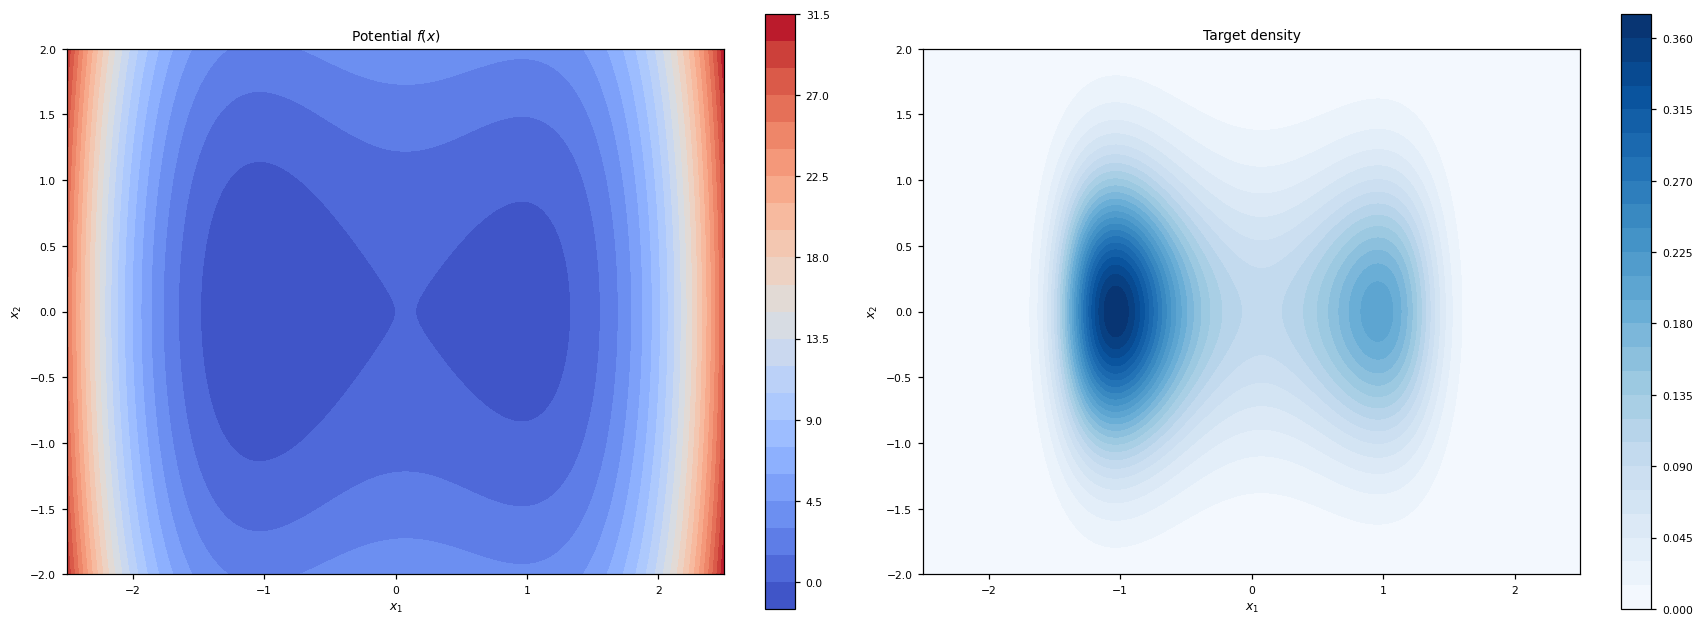

In [3]:
from data_distributions import double_well_2d as double_well

x_axis = np.linspace(-2.5, 2.5, 300)
y_axis = np.linspace(-2.0, 2.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)
# Flat (H*W, 2) batch -- potential / gibbs_density operate on (N, 2) inputs.
grid_points = np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)

potential_grid = double_well.potential(grid_points).reshape(grid_x.shape)
density_grid = double_well.gibbs_density(grid_points).reshape(grid_x.shape)

# The target density, on its own (no samples yet).
plot.potential_and_density_2d(grid_x, grid_y, potential_grid, density_grid)

To draw samples from this density we use the Langevin Monte Carlo Algorithm. This algorithm requires the gradient $\nabla f$, which is here a 2D vector field. The sampling iterations are

$$ X_{k+1} =  X_k - \eta\,\nabla f( X_k)
+ \sqrt{2\eta}\, W_k,
\qquad W_k \sim \mathcal N(0, I_2).$$

Running many independent chains in parallel fills **both** wells; we then overlay
the generated samples on the density to check they agree.

### Question 1 — Compute the potential gradient

**File:** `data_distributions/double_well_2d.py` &nbsp; **Functions:** `df1`, `df2`

The potential factorizes across the two coordinates,

$$f(x_1, x_2) = f_1(x_1) + f_2(x_2),$$

so its gradient is just the stack of the two component derivatives:

$$\nabla f(x_1, x_2) = \big(f_1'(x_1),\; f_2'(x_2)\big).$$

Implement the two derivatives `df1` and `df2` functions of one variable. 

**What to check.** Once filled, the next cell, which runs Langevin Monte Carlo should execute without raising `NotImplementedError`, and produce samples drawn from the righ distribution.

### Question 2 - Implement the Langevin update rule

**File:** `sampling/langevin.py` &nbsp; **Function:** `langevin_sample`


Specifically:

1. Draw `noise = np.random.randn(*x.shape)` — i.i.d. Gaussian noise
   with the same shape as the batch of chains `x`.
2. Update `x = x - eta * grad_f(x) + noise_scale * noise`, where the scalar
   `noise_scale = sqrt(2 * eta)` is already pre-computed above the loop.

**What to check.** Once filled, the next plot should show the empirical
histogram of the chains overlaying the analytic Gibbs density across both
wells (the deeper one carrying more mass). If only one well is populated,
you likely forgot the noise term: without it the chain is pure gradient
descent and gets trapped in the closer minimum.

In [4]:
from sampling.langevin import langevin_sample


rng = np.random.default_rng(0)
initial_states = rng.uniform([-2.0, -1.5], [2.0, 1.5], size=(8000, 2))
langevin_samples = langevin_sample(double_well.grad_potential, initial_states,
                                   eta=5e-3, n_steps=1_000)


100%|██████████| 1000/1000 [00:00<00:00, 2558.99it/s]


Let's plot the generated samples and check the agreement with the analytical distribution.

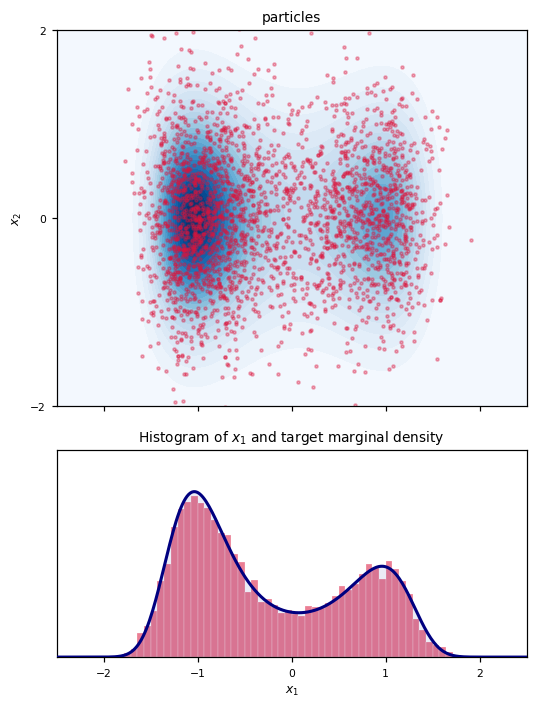

In [5]:

plot.density_marginal_snapshot(
    (grid_x, grid_y, density_grid), x_axis, double_well.x_marginal(x_axis),
    langevin_samples, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0))

## Section 2 — Learning to Sample: a 2D Gaussian Mixture

In Section 1, the analytic expression of the target density was known, which allowed us to compute the Langevin iterations with the potential gradient $\nabla f(x)$.

Generative-modeling aims at learning the data distribution from samples, and to draw new ones, without an analytical model. 

In this section, we learn a diffusion model on a two-dimensional bimodal data distribution.

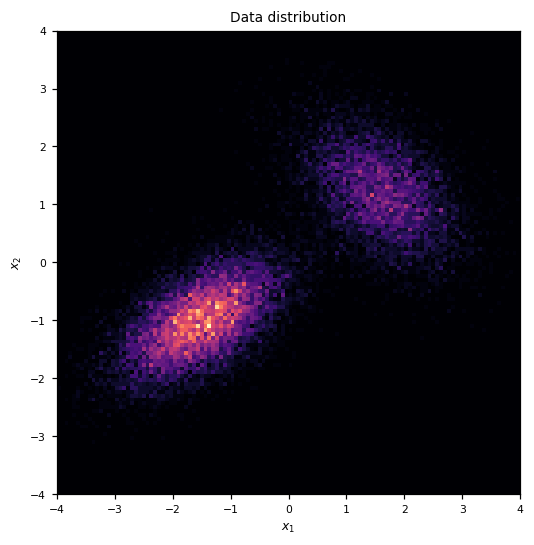

In [6]:
from data_distributions import gaussian_mixture_2d as mixture


mixture_data = mixture.sample(20000, rng=np.random.default_rng(0)).astype(np.float32)

plot.samples_2d(mixture_data, title="Data distribution")

 The point cloud has two well-separated, tilted blobs
of unequal mass, generated from a mixture of two Gaussians

$$p(x) = w_1\,\mathcal N(x;\mu_1,\Sigma_1) + w_2\,\mathcal N(x;\mu_2,\Sigma_2),
\qquad (w_1,w_2) = (0.65,\,0.35).$$

Being a mixture, it is exactly samplable and its score is known in closed
form — the responsibility-weighted blend of the two linear scores,

$$\nabla\log p(x) = -\sum_k r_k(x)\,\Sigma_k^{-1}(x-\mu_k),
\qquad r_k(x) = \frac{w_k\,\mathcal N_k(x)}{\sum_j w_j\,\mathcal N_j(x)}.$$


Our goal here is to sample from this toy bimodal data distribution.


### A failure mode for Langevin Monte Carlo

We have $\nabla\log p$ in closed form, so we could try to  sampler
directly. But the two components are far apart, separated by a deep
low-density valley where the score $\nabla\log p \approx 0$. In this area, the chain gets almost
no push across. Within any practical budget it stays trapped in whichever
mode it started in.

The number of steps required to cross a potential barrier can be shown to be exponential in the potential difference.

Let's run the  Langevin Monte Carlo algorithm from a
uniform start and compare the empirical histograms of the data and of
Langevin, for the first component $x_1$.


In [7]:
rng = np.random.default_rng(0)
initial_states = rng.uniform(-4, 4, size=(8000, 2))
langevin_samples = langevin_sample(mixture.grad_potential, initial_states,
                                   eta=3e-3, n_steps=1_000)


100%|██████████| 1000/1000 [00:03<00:00, 330.18it/s]


### Question 3 - Plot histograms


**File:** `plot/diffusion.py` &nbsp; **Function:** `overlay_histograms`

Plot and overlay two histograms of the 

**What to check.** Once filled, the next plot should show the empirical
histogram of the chains overlaying the analytic Gibbs density across both
wells (the deeper one carrying more mass). If only one well is populated,
you likely forgot the noise term: without it the chain is pure gradient
descent and gets trapped in the closer minimum.

Overlay the histograms of the data and of the generated samples for the first component, and check that Langevin Monte Carlo fails to reproduce this data distribution. 

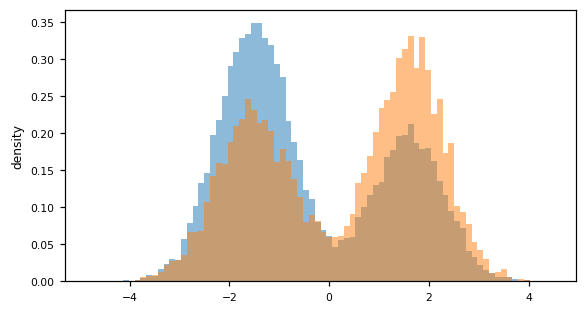

In [8]:
plot.overlay_histograms(mixture_data[:, 0], langevin_samples[:, 0])

### A score-based diffusion model

A diffusion model avoids density barriers by sampling a sequence of regularized distribution.

Let $X \sim p_\star$ and $\varepsilon \sim \mathcal{N}(0, I_d)$. We define a noise schedule $(\mu_t, \sigma_t)$ interpolating between pure noise at $t=0$ and the data at $t=1$, and the corresponding random variable

$$X_t = \mu_t\, X + \sigma_t\,\varepsilon,
\qquad \mu_t^2 + \sigma_t^2 = 1\ \text{(variance-preserving)}.$$

and $p_t$ the density of $X_t$.

At initial time $\mu_0 \approx 0,\ \sigma_0 \approx 1$ models a (single) Gaussian blob, and at terminal time
$\mu_1 = 1,\ \sigma_1 \approx 0$ models the data distribution.

Throughout, the diffusion model runs forward in
time: $t=0$ is pure noise and $t=1$ is the data, so generation flows from noise
up to the learned density.

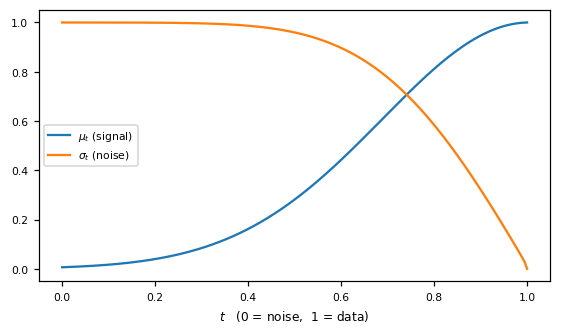

In [9]:
from sampling.schedule import mu_schedule, sigma_schedule

times = torch.linspace(0, 1, 200)
plot.noise_schedule(times, mu_schedule(times), sigma_schedule(times))

Concretely, $X_t = \mu_t X + \sigma_t \varepsilon$ is a linear interpolation in distribution between the data ($t=1$) and pure noise ($t=0$). Below, we visualize this on the Gaussian mixture — at each noise level $\sigma$ the two blobs contract by $\mu_t = \sqrt{1-\sigma^2}$ and are blurred by additive noise of width $\sigma$, until they merge into a single isotropic Gaussian.

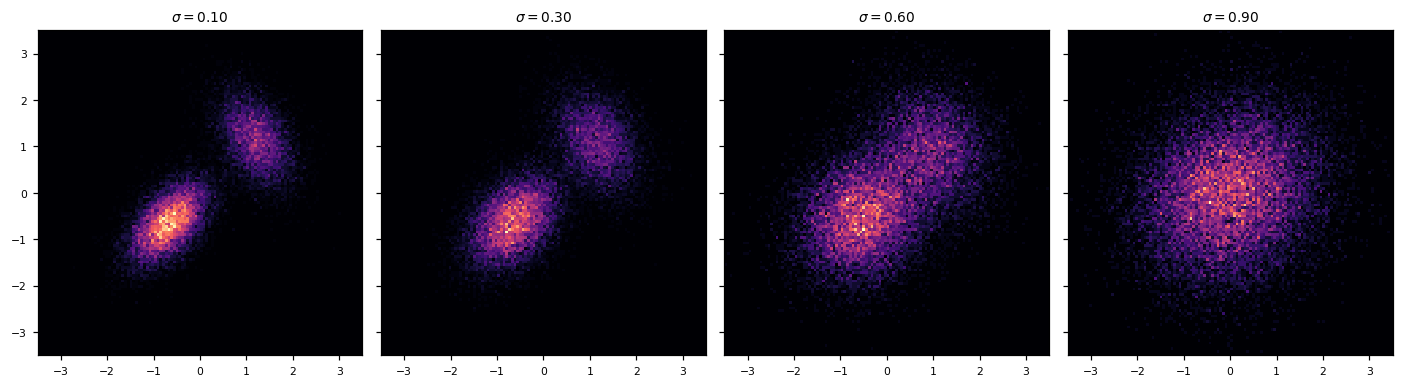

In [10]:
# Standardize so the VP schedule (which targets unit variance) applies cleanly.
_mu, _sd = mixture_data.mean(0), mixture_data.std(0)
mixture_standardized = (mixture_data - _mu) / _sd

plot.noised_samples_across_sigma(mixture_standardized,
                                 sigma_levels=[0.1, 0.3, 0.6, 0.9])

### Training: denoising score matching

By Tweedie's formula, the noisy-data score $\nabla \log p_t(x)$ is interpreted as a one-shot mean squared error denoiser: for a sample noised at level $(\mu_t, \sigma_t)$,

$$ \mathbb{E}[\mu_t X \mid X_t = x] \;=\; x + \sigma_t^{2}\, \nabla \log p_t(x).$$

Therefore, the score  $\nabla \log p_t(x)$ minimizes the following loss over functions $s(\cdot, t)$

$$ \mathbb{E} \left[ \Vert X_t + \sigma_t^2\, s(X_t, t) - \mu_t X \Vert^2 \right],$$


and can be learned with a parametric model $s(x, t ; \theta)$ by minimizing the empirical loss
$$L(\theta) = \mathbb{E} \left[\|\sigma_t\, s(X_t, t ; \theta) + \varepsilon\|^2 \right].$$

### Question 4 — Implement the denoising score matching loss

**File:** `learning/training.py` &nbsp; **function:** `dsm_loss`

For a batch of samples $x_0$, sample a random time $t \sim \mathcal{U}(0, 1)$ and a
noise vector $\varepsilon \sim \mathcal{N}(0, I)$, then form the noised sample
$x_t = \mu_t x_0 + \sigma_t\,\varepsilon$. 

Specifically, fill in the body to:

1. Draw `eps = torch.randn_like(x0)`.
2. Build `x_t = mu * x0 + sigma * eps` (the `mu`, `sigma` of shape `(B, 1)`
   are already pre-computed and broadcast across the feature dimension).
3. Evaluate `score = model(x_t, t)`.
4. Build `residual = sigma * score + eps` and return
   `(residual**2).sum(-1).mean()`.

**What to check.** The training-loss curve should drop quickly over the
first few hundred steps and then plateau — a flat or NaN curve almost
always means a shape bug in step 2 or 4.

100%|██████████| 3000/3000 [00:04<00:00, 678.30it/s]


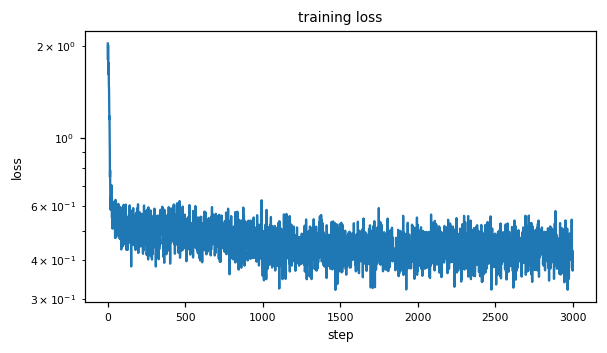

In [11]:
from learning.networks import ScoreNet2D
from learning.training import train_score_model

# Standardize per-dimension (the noise schedule targets unit variance).
data_mean, data_std = mixture_data.mean(0), mixture_data.std(0)
mixture_data_standardized = (mixture_data - data_mean) / data_std

score_model = ScoreNet2D().to(device)
score_model, losses = train_score_model(score_model, mixture_data_standardized,
                                        n_epochs=3000, batch_size=512, lr=1e-3)

plot.loss_curve(losses, title="training loss", log=True)

### Learned score visualization

At the data end $t\approx1$ the network should recover
the *data* score $\nabla\log p$: arrows point *uphill in probability*, flowing
into the two Gaussian blobs and away from the low-density valley between them. We
draw each arrow as a unit-length **direction** colored by magnitude, so the
geometry stays readable even where the score is large. The analytic field (left)
is the closed-form mixture score; the learned one (right) is what denoising score
matching recovered.

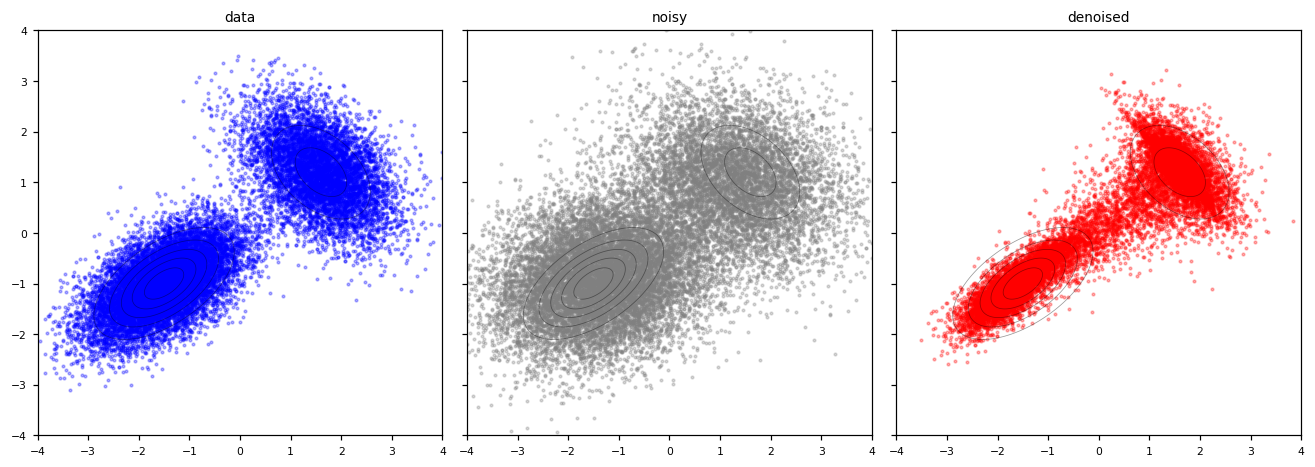

In [12]:
from sampling.diffusion_sampler import tweedie_denoise
from sampling.schedule import mu_schedule, sigma_schedule, time_from_sigma

# Intermediate noise level sigma; the matching time t comes from the schedule.
sigma_demo = 0.5
t_demo = float(time_from_sigma(sigma_demo))
mu_demo, sig_demo = float(mu_schedule(t_demo)), float(sigma_schedule(t_demo))

x0 = torch.from_numpy(mixture_data_standardized)
eps = torch.randn_like(x0)
x_noisy = mu_demo * x0 + sig_demo * eps
x_denoised = tweedie_denoise(score_model, x_noisy.to(device), t_demo).cpu()

# Back to physical space for the visualization.
noisy_phys = x_noisy.numpy() * data_std + data_mean
denoised_phys = x_denoised.numpy() * data_std + data_mean


x_axis = np.linspace(-4.0, 4.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, x_axis)
density_grid = mixture.gibbs_density(np.stack([grid_x, grid_y], axis=-1))

plot.denoiser_panels_2d(mixture_data, noisy_phys, denoised_phys,
                        density_grid=(grid_x, grid_y, density_grid),
                        extent=4.0)

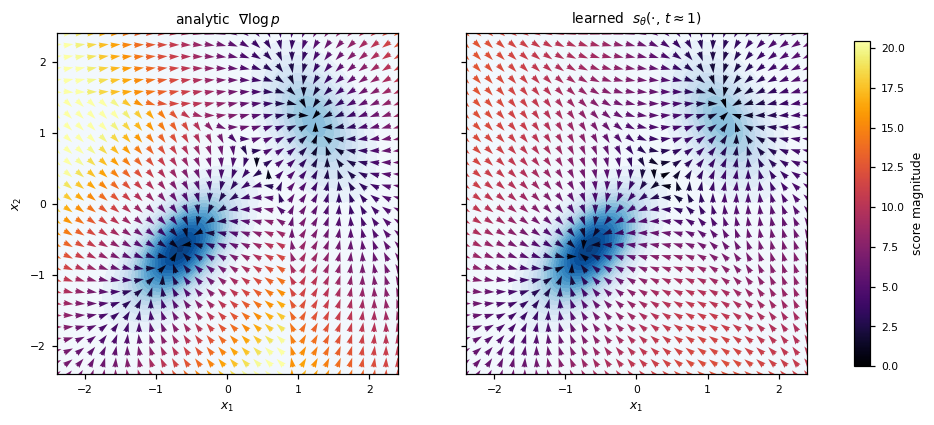

In [13]:
plot.score_fields(score_model, mixture.score, mixture.gibbs_density,
                  data_mean, data_std)

The noised density $p(x_t ; \mu, \sigma)$ is the data blurred by a Gaussian of width $\sigma$ and shrunk
by $\mu=\sqrt{1-\sigma^2}$. At small $\sigma$ the field shows the two-basin
structure of the data score; as $\sigma$ grows the two blobs contract and merge
into a single Gaussian, and the learned field collapses to one inward pull
toward the origin. 

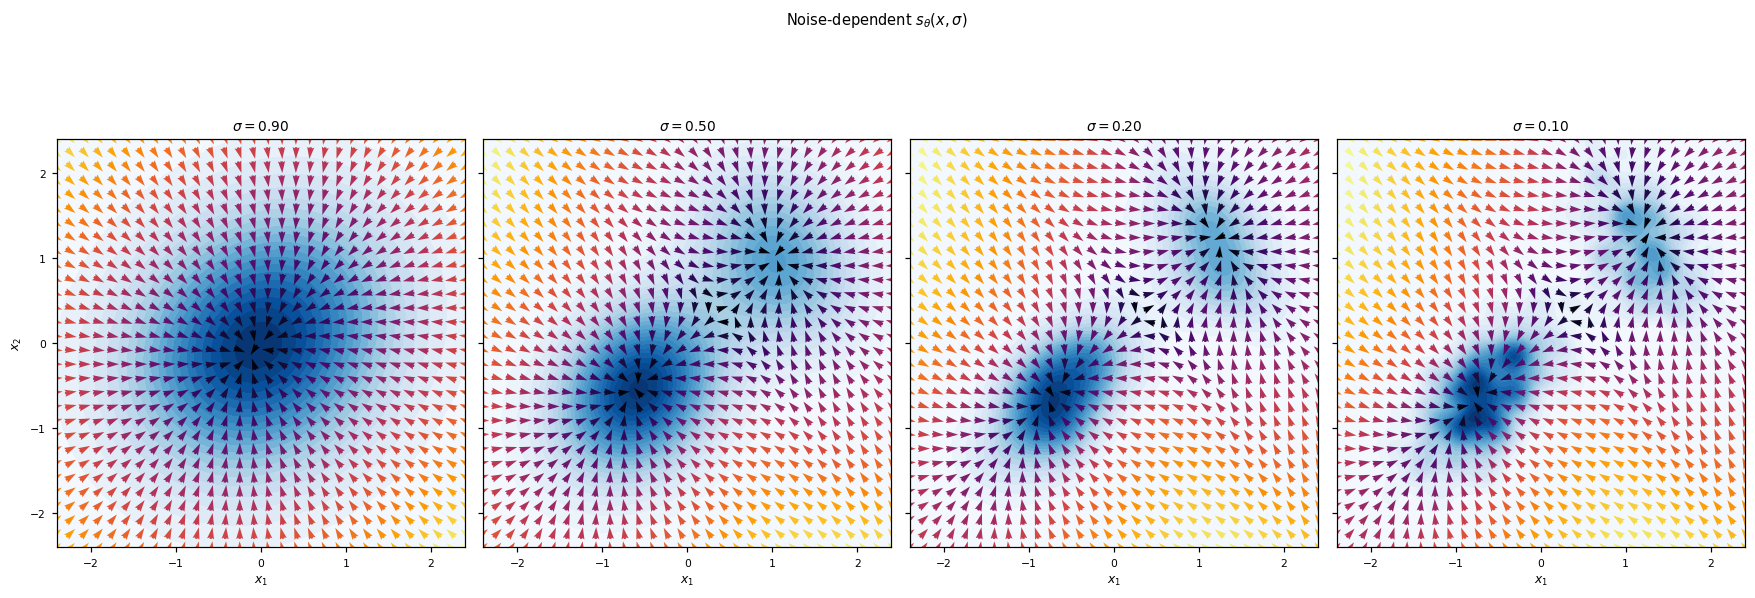

In [14]:
plot.field_across_noise(score_model, mixture_data_standardized,
                        sigma_levels=[0.9, 0.5, 0.2, 0.1])

### Question 5 — Implement the generative sampling step

**File:** `sampling/diffusion_sampler.py` &nbsp; **Function:** `generate_samples`

The learned score $s_\theta(x, t) \approx \nabla \log p_t(x)$ gives us, at every noise level, the local direction of increasing density. We use it inside a discrete-time iteration that morphs Gaussian noise at $t=0$ into samples of $p_{\text{data}}$ at $t=1$.

Discretize $[0, 1]$ into $N$ steps with $\Delta t = 1/N$ and times $t_0 = 0 < t_1 < \cdots < t_N = 1$. Define the *effective step size at time $t_k$*

$$\eta_k \;:=\; \tfrac12\,\beta(t_k)\,\Delta t,$$

where $\beta(t) = \beta_{\min} + (1-t)(\beta_{\max} - \beta_{\min})$ is the noise-rate schedule (large near $t = 0$, small near $t = 1$). Starting from $X_0 \sim \mathcal N(0, I)$, the sampling update is

$$\boxed{\;X_{k+1} \;=\; (1 + \eta_k)\,X_k \;+\; 2\eta_k\, s_\theta(X_k, t_k) \;+\; \sqrt{2\eta_k}\, W_k, \qquad W_k \sim \mathcal N(0, I).\;}$$

This is an **efficient sampling algorithm**: each step is one forward pass through the score network plus a Gaussian draw — no density evaluation, no rejection, no Metropolis correction.

**Implementation** Inside the time loop, implement one update step:

1. `score = model(x, t_batch)`
2. `eta = 0.5 * beta_t * dt`
3. `x = (1 + eta) * x + 2 * eta * score`
4. On every step except the last, add Gaussian noise: `x = x + torch.sqrt(2 * eta) * torch.randn_like(x)`. Dropping the noise on the last step is a standard "final-denoise" trick.

**What to check**  Once filled, both the 2D mixture sampler (Section 2) and the 3D Lorenz sampler (Section 3) start working: the mixture cell should show generated points covering both blobs in roughly $65/35$ proportion, and the Lorenz cell should trace out the butterfly attractor. Common bugs: missing the noise term collapses the sampler to its deterministic limit, which still looks reasonable but loses diversity.

In [15]:
from sampling.diffusion_sampler import generate_samples

x_axis = np.linspace(-4.0, 4.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, x_axis)
density_grid = mixture.gibbs_density(np.stack([grid_x, grid_y], axis=-1))

# Generate by integrating the generative SDE forward in time, then un-standardize.
generated_samples = generate_samples(score_model, n_samples=6000, dim=2,
                                      n_steps=1000, seed=0)
generated_samples = generated_samples.cpu().numpy() * data_std + data_mean

100%|██████████| 1000/1000 [00:02<00:00, 442.77it/s]


Let's check the agreement between the generated samples and the data distribution.

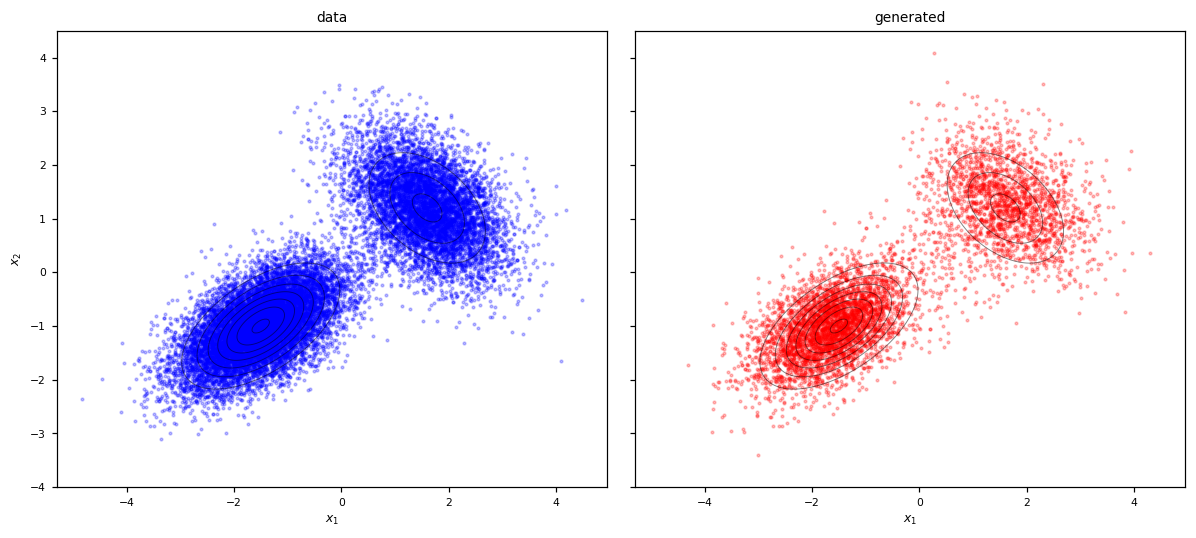

In [16]:

plot.samples_comparison_2d((grid_x, grid_y, density_grid), mixture_data,
                           generated_samples,
                           titles=("data", "generated"))

## Section 3 — Lorenz '63 Diffusion Model

We now scale up to 3D. The **Lorenz '63** system is chaotic; points along a long
trajectory sample its invariant measure — the two-winged *butterfly attractor*.
We train a `ScoreNet3D` on this point cloud and then **generate** new states by
running the diffusion model forward in time (from noise at $t=0$ to data at
$t=1$). Good samples should re-trace the butterfly.

training data shape: (22000, 3)


100%|██████████| 4000/4000 [00:13<00:00, 303.89it/s]


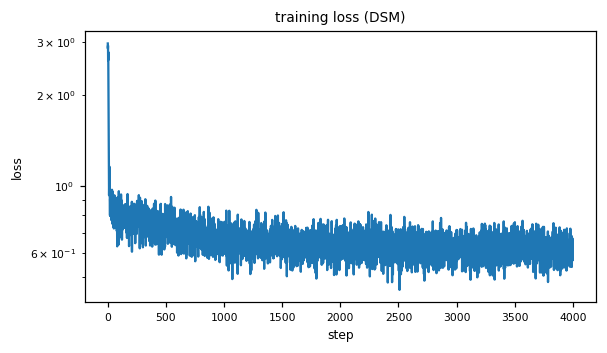

In [17]:
from data_distributions.lorenz import simulate_attractor
from learning.networks import ScoreNet3D

lorenz_data = simulate_attractor(n_steps=25000, dt=0.01, burn_in=3000).astype(np.float32)
lorenz_mean, lorenz_std = lorenz_data.mean(0), lorenz_data.std(0)
lorenz_data_standardized = (lorenz_data - lorenz_mean) / lorenz_std
print("training data shape:", lorenz_data.shape)

score_model_3d = ScoreNet3D().to(device)
score_model_3d, losses_3d = train_score_model(score_model_3d, lorenz_data_standardized,
                                              n_epochs=4000, batch_size=512, lr=1e-3)
plot.loss_curve(losses_3d, title="training loss (DSM)", log=True)

### The score network as a denoiser (3D)

We visualize the action of the learned denoiser on the samples as in the previous section

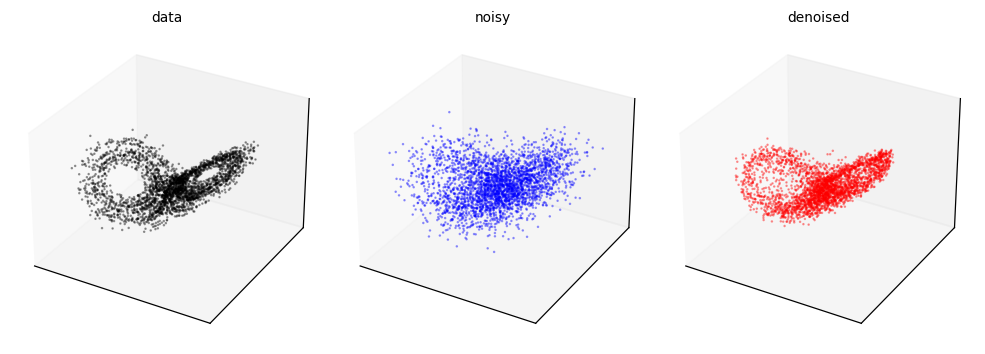

In [21]:
sigma_demo = 0.5
t_demo = float(time_from_sigma(sigma_demo))
mu_demo, sig_demo = float(mu_schedule(t_demo)), float(sigma_schedule(t_demo))

rng = np.random.default_rng(0)
idx = rng.choice(len(lorenz_data), size=3000, replace=False)
x0 = torch.from_numpy(lorenz_data_standardized[idx])
eps = torch.randn_like(x0)
x_noisy = mu_demo * x0 + sig_demo * eps
x_denoised = tweedie_denoise(score_model_3d, x_noisy.to(device), t_demo).cpu()

plot.denoiser_panels_3d(lorenz_data[idx],
                        x_noisy.numpy() * lorenz_std + lorenz_mean,
                        x_denoised.numpy() * lorenz_std + lorenz_mean)

We now visualize the learned samples

100%|██████████| 1000/1000 [00:05<00:00, 194.82it/s]


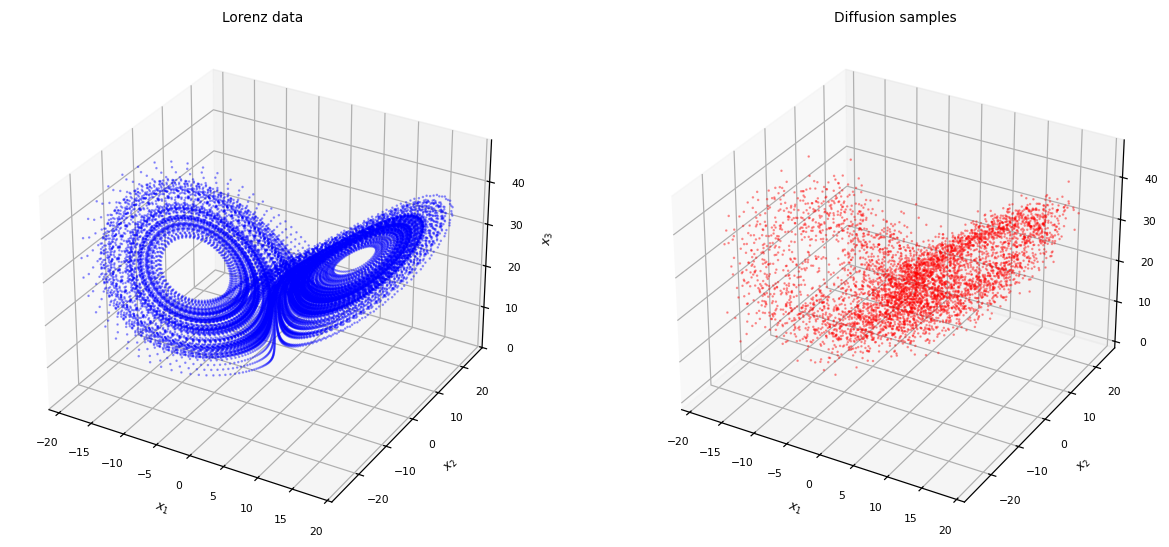

In [18]:
generated_standardized = generate_samples(score_model_3d, n_samples=5000, dim=3,
                                          n_steps=1000, seed=0)
generated_states = generated_standardized.cpu().numpy() * lorenz_std + lorenz_mean

plot.comparison_3d(lorenz_data, generated_states)

## Section 4 — Inverse Problem: Conditional Sampling

Finally, a data-assimilation flavored task. We observe **only the third coordinate $x_3$**
of a hidden Lorenz state, through a noisy linear sensor

$$y = Hx + \nu,\quad H=[0,0,1],\quad \nu\sim\mathcal N(0,\sigma_{\text{obs}}^2).$$

We want the **posterior** $p(x\mid y)$. By Bayes, its score is just a sum:

$$\nabla_x\log p(x\mid y) = \underbrace{\nabla_x\log p(x)}_{s_\theta\ (\text{Section 3})}
+ \underbrace{\nabla_x\log p(y\mid x)}_{\text{closed-form Gaussian}}.$$

We plug this posterior score into the **same forward-time generative sampler**.
The butterfly attractor is left–right symmetric about the $x_3$-axis: for a given
$x_3$ value, states with that altitude exist on **both wings**. So $x_3$ alone cannot
tell us which lobe the truth is on, and the posterior over the full 3D state is
**bimodal** — the ensemble should split into the two wings, discriminated by the
sign of $x_1$.

### Question 6.1 — Implement the likelihood score

**File:** `sampling/inverse_problem.py` &nbsp; **Function:** `likelihood_score`

For a linear-Gaussian observation $y = Hx + \nu$ with
$\nu \sim \mathcal{N}(0, R)$ and $R = \sigma_{\text{obs}}^2 I$, the log-likelihood
is quadratic in $x$, so its gradient is the (precision-weighted) residual:

$$\nabla_x \log p(y \mid x) = H^\top R^{-1}(y - Hx)
= \frac{1}{\sigma_{\text{obs}}^2}\, H^\top (y - Hx).$$

Implement it in two lines using batched matmuls:

```python
residual = y - x @ H.T                # (B, m)
return  residual @ H / sigma_obs**2   # (B, d)
```

### Question 6.2 — Combine prior and likelihood (Bayes decomposition)

**Same file** &nbsp; **Function:** `compute_posterior_score` (the *likelihood-only* branch)

Bayes' rule gives a clean **additive** decomposition of scores:

$$\nabla_x \log p(x \mid y) = \underbrace{\nabla_x \log p(x)}_{s_\theta(x, t)}
\;+\; \underbrace{\nabla_x \log p(y \mid x)}_{\text{Q6.1}}.$$

The prior score `s_theta(x, t)` is already evaluated for you (`score = model(x, t_batch)`).
In the `else` branch (likelihood-only, where `B_inv is None`), just add the
likelihood score from Q6.1 and return:

```python
score = score + likelihood_score(x, y, H, sigma_obs)
return score
```

(Do *not* touch the `if B_inv is not None:` branch above — that is a more
advanced 3D-Var Gaussian-guidance variant that is shipped complete.)

**What to check.** The posterior ensemble should split into **both wings** of
the Lorenz butterfly: states with positive *and* negative $x$ both appear,
since the observation $z$ alone cannot tell the two lobes apart. A unimodal
result means the likelihood term is being applied too aggressively (or the
prior score got dropped); a result indifferent to $y$ means the likelihood
term was not added at all.

In [19]:
from sampling.inverse_problem import ObservationOperator, conditional_sample

# Pick a truth state on the attractor and synthesize a noisy x_3-observation.
# Sampling from the trajectory keeps the observation consistent with the prior.
truth = np.array([-19., -20.,  41.]
                 )                 # shape (3,)
observation_noise_std = 1.0                   # physical units
rng = np.random.default_rng(42)
x3_obs = truth[2] + observation_noise_std * rng.standard_normal()
print(f"truth state: {truth.round(2)}   observed x_3: {x3_obs:.2f}")

# The sampler works in standardized space, so standardize both y and sigma_obs
# along the x_3-coordinate (last column).
observation = ObservationOperator(sigma_obs=observation_noise_std / lorenz_std[2])
y_standardized = torch.tensor([(x3_obs - lorenz_mean[2]) / lorenz_std[2]],
                              dtype=torch.float32)

posterior_standardized = conditional_sample(score_model_3d, y_standardized, observation,
                                            n_samples=2000, dim=3, n_steps=1000, seed=0)
posterior_samples = posterior_standardized.cpu().numpy() * lorenz_std + lorenz_mean

# Sign of x_1 is the natural wing discriminator for the Lorenz butterfly.
wing_mask = posterior_samples[:, 0] > 0

truth state: [-19. -20.  41.]   observed x_3: 41.30


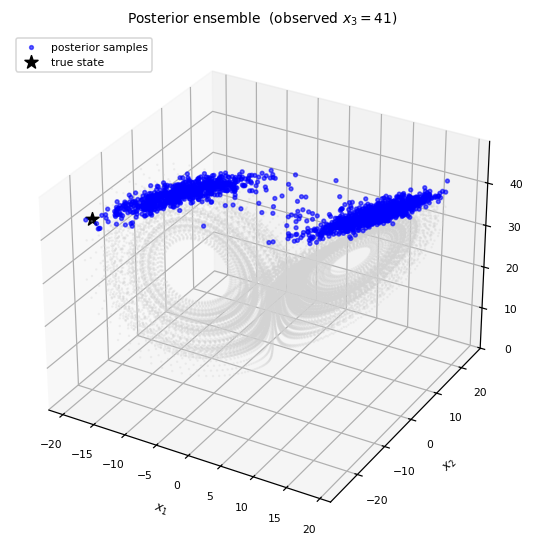

In [20]:
plot.posterior_ensemble(lorenz_data, posterior_samples, x3_obs, truth=truth)

**Takeaway** A single diffusion prior, trained once on the attractor, was
re-used to solve an inverse problem *without retraining*: we only added a
closed-form likelihood score. The posterior concentrates around the observed
$x_3$ while expressing genuine uncertainty about the unobserved $x_1, x_2$.